In [2]:
!pip install -q huggingface_hub datasets pandas numpy tqdm matplotlib seaborn scipy textstat scikit-learn adjustText syllables fasttext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 22.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 52.7 MB/s eta 0:00:00:00:01


Language identificztion model used: https://fasttext.cc/docs/en/language-identification.html

In [3]:
!wget https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin

--2026-04-06 09:15:36--  https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 99.84.118.60, 99.84.118.67, 99.84.118.30, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|99.84.118.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 131266198 (125M) [application/octet-stream]
Saving to: ‘lid.176.bin.1’

lid.176.bin.1       100%[===================>] 125.18M   266MB/s    in 0.5s    

2026-04-06 09:15:37 (266 MB/s) - ‘lid.176.bin.1’ saved [131266198/131266198]



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from scipy.stats import (pointbiserialr, mannwhitneyu, pearsonr, spearmanr,
                          binomtest, entropy as scipy_entropy)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import textstat
from huggingface_hub import login
from datasets import load_dataset
import fasttext


In [19]:
model = fasttext.load_model("lid.176.bin")

In [6]:
ds_v = load_dataset('ministere-culture/comparia-votes')

README.md: 0.00B [00:00, ?B/s]

votes.parquet:   0%|          | 0.00/789M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/164367 [00:00<?, ? examples/s]

In [10]:
ds_v

DatasetDict({
    train: Dataset({
        features: ['id', 'timestamp', 'model_a_name', 'model_b_name', 'model_pair_name', 'chosen_model_name', 'opening_msg', 'both_equal', 'conversation_a', 'conversation_b', 'conv_turns', 'selected_category', 'is_unedited_prompt', 'conversation_pair_id', 'session_hash', 'visitor_id', 'conv_comments_a', 'conv_comments_b', 'conv_useful_a', 'conv_useful_b', 'conv_creative_a', 'conv_creative_b', 'conv_clear_formatting_a', 'conv_clear_formatting_b', 'conv_incorrect_a', 'conv_incorrect_b', 'conv_superficial_a', 'conv_superficial_b', 'conv_instructions_not_followed_a', 'conv_instructions_not_followed_b', 'system_prompt_b', 'system_prompt_a', 'conv_complete_a', 'conv_complete_b'],
        num_rows: 164367
    })
})

In [5]:
print(ds_v.keys())

dict_keys(['train'])


In [14]:
df_votes = ds_v['train'].to_pandas()

In [18]:
df_votes.head(5)

,id,timestamp,model_a_name,model_b_name,model_pair_name,chosen_model_name,opening_msg,both_equal,conversation_a,conversation_b,...,conv_incorrect_a,conv_incorrect_b,conv_superficial_a,conv_superficial_b,conv_instructions_not_followed_a,conv_instructions_not_followed_b,system_prompt_b,system_prompt_a,conv_complete_a,conv_complete_b
0,128695,2025-11-30 13:23:58.228862,grok-4-fast,magistral-medium,"[grok-4-fast, magistral-medium]",magistral-medium,"Sens des prénoms vincent, jérome et irène",False,"[{'content': 'Sens des prénoms vincent, jérome...","[{'content': 'Sens des prénoms vincent, jérome...",...,False,False,False,False,False,False,None,None,False,False
1,128697,2025-11-30 13:38:40.997653,grok-4.1-fast,mistral-medium-2508,"[grok-4.1-fast, mistral-medium-2508]",mistral-medium-2508,Je ne veux passer a la suite pour les résultats,False,[{'content': 'Je ne veux passer a la suite pou...,[{'content': 'Je ne veux passer a la suite pou...,...,False,False,False,False,False,False,None,None,False,False
2,128700,2025-11-30 14:20:50.714161,gemma-3-12b,gpt-5-mini,"[gemma-3-12b, gpt-5-mini]",gpt-5-mini,Meilleure IA reconnue pour préparer un entreti...,False,[{'content': 'Meilleure IA reconnue pour prépa...,[{'content': 'Meilleure IA reconnue pour prépa...,...,False,False,False,False,False,False,None,None,False,False
3,128702,2025-11-30 14:29:35.757635,qwen3-30b-a3b,Apertus-70B-Instruct-2509,"[Apertus-70B-Instruct-2509, qwen3-30b-a3b]",None,Quelle est la ville idéale pour élever ses enf...,True,[{'content': 'Quelle est la ville idéale pour ...,[{'content': 'Quelle est la ville idéale pour ...,...,False,False,False,False,False,False,None,None,False,False
4,128705,2025-11-30 14:54:54.746896,glm-4.6,mistral-small-2506,"[glm-4.6, mistral-small-2506]",None,Fais 5 poèmes sur les pieds,True,"[{'content': 'Fais 5 poèmes sur les pieds ', '...","[{'content': 'Fais 5 poèmes sur les pieds ', '...",...,False,False,False,False,False,False,None,None,False,False


In [42]:
df_votes['conversation_a'][0]

array([{'content': 'Sens des prénoms vincent, jérome et irène', 'metadata': {'duration': None, 'generation_id': None, 'is_cached': None, 'output_tokens': None}, 'reasoning': None, 'reasoning_content': None, 'role': 'user'},
       {'content': '### Signification des prénoms Vincent, Jérôme et Irène\n\nVoici une explication étymologique et historique brève pour chacun de ces prénoms, basée sur leurs origines latines et grecques. Ces significations proviennent de racines anciennes et peuvent varier légèrement selon les contextes culturels.\n\n- **Vincent** :  \n  D\'origine latine, dérivé de *Vincentius*, qui vient du verbe *vincere* signifiant "vaincre" ou "conquérir". Il porte donc le sens de "victorieux" ou "conquérant". Ce prénom est populaire en France depuis le Moyen Âge, associé à des figures comme saint Vincent de Saragosse, martyr chrétien.\n\n- **Jérôme** :  \n  Forme française du prénom latin *Hieronymus*, lui-même issu du grec *Hieronymos* (Ἱερώνυμος). Il se compose de *hieros

In [59]:
def extract_text_from_array(conv_array):
    if isinstance(conv_array, np.ndarray):
        conv_list = conv_array.tolist()
    elif isinstance(conv_array, list):
        conv_list = conv_array
    else:
        return ""  # empty if not list/array
    texts = []
    for item in conv_list:
        if isinstance(item, dict) and "content" in item:
            text = str(item["content"]).strip()
            if text:
                texts.append(text)
    return " ".join(texts)  # always a single string

In [60]:
# Extract text from both columns
df_votes['conversation_a_text'] = df_votes['conversation_a'].apply(extract_text_from_array)
df_votes['conversation_b_text'] = df_votes['conversation_b'].apply(extract_text_from_array)

In [61]:
df_votes['conversation_a_text']

0         Sens des prénoms vincent, jérome et irène ### ...
1         Je ne veux passer a la suite pour les résultat...
2         Meilleure IA reconnue pour préparer un entreti...
3         Quelle est la ville idéale pour élever ses enf...
4                          Fais 5 poèmes sur les pieds None
                                ...                        
164362    A Cranefly In September\nA Woman Unconscious\n...
164363    d It seems like you started to type something,...
164364    je cherche des information sur initiative cito...
164365    je cherche des information sur initiative cito...
164366    je suis directeur d'école, école primaire mate...
Name: conversation_a_text, Length: 164367, dtype: object

In [62]:
df_votes['conversation_b_text']

0         Sens des prénoms vincent, jérome et irène Voic...
1         Je ne veux passer a la suite pour les résultat...
2         Meilleure IA reconnue pour préparer un entreti...
3         Quelle est la ville idéale pour élever ses enf...
4         Fais 5 poèmes sur les pieds Bien sûr ! Voici c...
                                ...                        
164362    A Cranefly In September\nA Woman Unconscious\n...
164363    d It looks like you've just typed "d". Could y...
164364    je cherche des information sur initiative cito...
164365    je cherche des information sur initiative cito...
164366    je suis directeur d'école, école primaire mate...
Name: conversation_b_text, Length: 164367, dtype: object

In [63]:
# Convert to strings and remove newlines
texts_a = df_votes['conversation_a_text'].astype(str).str.replace("\n", " ").tolist()
texts_b = df_votes['conversation_b_text'].astype(str).str.replace("\n", " ").tolist()

In [64]:
# Vectorized language prediction
labels_a, probs_a = model.predict(texts_a)
labels_b, probs_b = model.predict(texts_b)

In [66]:
# Extract first label from each sublist and clean
df_votes['lang_fasttext_a'] = [lbl[0].replace("__label__", "") for lbl in labels_a]
df_votes['lang_fasttext_b'] = [lbl[0].replace("__label__", "") for lbl in labels_b]

In [67]:
# Count French vs Non-French per column
num_french_a = (df_votes['lang_fasttext_a'] == 'fr').sum()
num_not_french_a = (df_votes['lang_fasttext_a'] != 'fr').sum()
num_french_b = (df_votes['lang_fasttext_b'] == 'fr').sum()
num_not_french_b = (df_votes['lang_fasttext_b'] != 'fr').sum()

In [68]:
print(f"conversation_a -> French: {num_french_a}, Not French: {num_not_french_a}")
print(f"conversation_b -> French: {num_french_b}, Not French: {num_not_french_b}")

conversation_a -> French: 155796, Not French: 8571
conversation_b -> French: 155732, Not French: 8635


In [69]:
# Summary table of combinations
summary = pd.crosstab(df_votes['lang_fasttext_a'] == 'fr', df_votes['lang_fasttext_b'] == 'fr')
summary.index = ['A Not French', 'A French']
summary.columns = ['B Not French', 'B French']

print("\nSummary table of French/Non-French combinations:")
print(summary)


Summary table of French/Non-French combinations:
              B Not French  B French
A Not French          6646      1925
A French              1989    153807


In [70]:
# one row where conversation_a is not French
example_non_french_a = df_votes[df_votes['lang_fasttext_a'] != 'fr'].head(1)

# Show conversation text and detected language
print("Detected language:", example_non_french_a['lang_fasttext_a'].values[0])
print("Conversation text:\n", example_non_french_a['conversation_a_text'].values[0])

Detected language: de
Conversation text:
 Erstelle ein prägnantes Kurzstatement (max. 200 Wörter) für meine Bewerbung als Bildungsreferent*in bei Grenzgänge e.V. in Berlin. 
Das Statement soll folgende Punkte klar und authentisch beantworten:

- Motivation: Warum mich die Themen globale Gerechtigkeit, Landwirtschaft, Lieferketten und Solidarökonomie besonders interessieren. 
- Erfahrung: Meine pädagogische Praxis mit Kindern und Jugendlichen (Grundschule bis Sek II), inkl. individueller Förderung in Chemie, Physik und Mathematik, projektbasiertes Lernen (z.B. Bau von Effektpedalen für E-Gitarren), sowie interaktive und diskriminierungskritische Methoden. 
- Kompetenzen: Konzeption und Durchführung von Workshops, Teamarbeit, klare Kommunikation, Mehrsprachigkeit (Deutsch, Englisch, Spanisch), Verbindung von Alltagsbezug und Wissenschaft zur Steigerung von Motivation und Lernerfolg. 
- Nachhaltigkeit & Praxis: Projekte wie „Citizen Science zu Mikroplastik in Berliner Gewässern“ mit inter

In [74]:
example_non_french_b = df_votes[df_votes['lang_fasttext_b'] != 'fr'].head(1)
print("Detected language:", example_non_french_b['lang_fasttext_b'].values[0])
print("Conversation text:\n", example_non_french_b['conversation_b_text'].values[0])

Detected language: en
Conversation text:
 Peux-tu me proposer des questions pour des élèves de 5e en anglais sur le tableau de Rockwell Freedom from Want? # Questions sur "Freedom from Want" de Norman Rockwell

## Questions de compréhension (niveau débutant)

1. **What can you see in the picture?** (Describe the scene)
2. **How many people are there?**
3. **What is the woman holding?**
4. **What food can you see on the table?**
5. **Where are the people? (in a kitchen, dining room, living room...)**

## Questions d'analyse (niveau intermédiaire)

6. **What celebration/holiday do you think it is? Why?**
7. **How do the people feel? Find adjectives to describe their emotions.**
8. **What is the atmosphere in this painting? (warm, cold, sad, joyful...)**
9. **Who do you think these people are? (family, friends...)**
10. **What does the title "Freedom from Want" mean?**

## Questions d'opinion (niveau avancé)

11. **Do you like this painting? Why or why not?**
12. **What does this painting

In [75]:
# Count rows where both columns have the same language
same_lang_count = (df_votes['lang_fasttext_a'] == df_votes['lang_fasttext_b']).sum()
print(f"Rows where conversation_a and conversation_b have the same detected language: {same_lang_count}")

Rows where conversation_a and conversation_b have the same detected language: 160223


/tmp/ipykernel_58/1286210794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_votes['lang_fasttext_a'], order=df_votes['lang_fasttext_a'].value_counts().index, palette="Blues_r")
/tmp/ipykernel_58/1286210794.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_votes['lang_fasttext_b'], order=df_votes['lang_fasttext_b'].value_counts().index, palette="Greens_r")


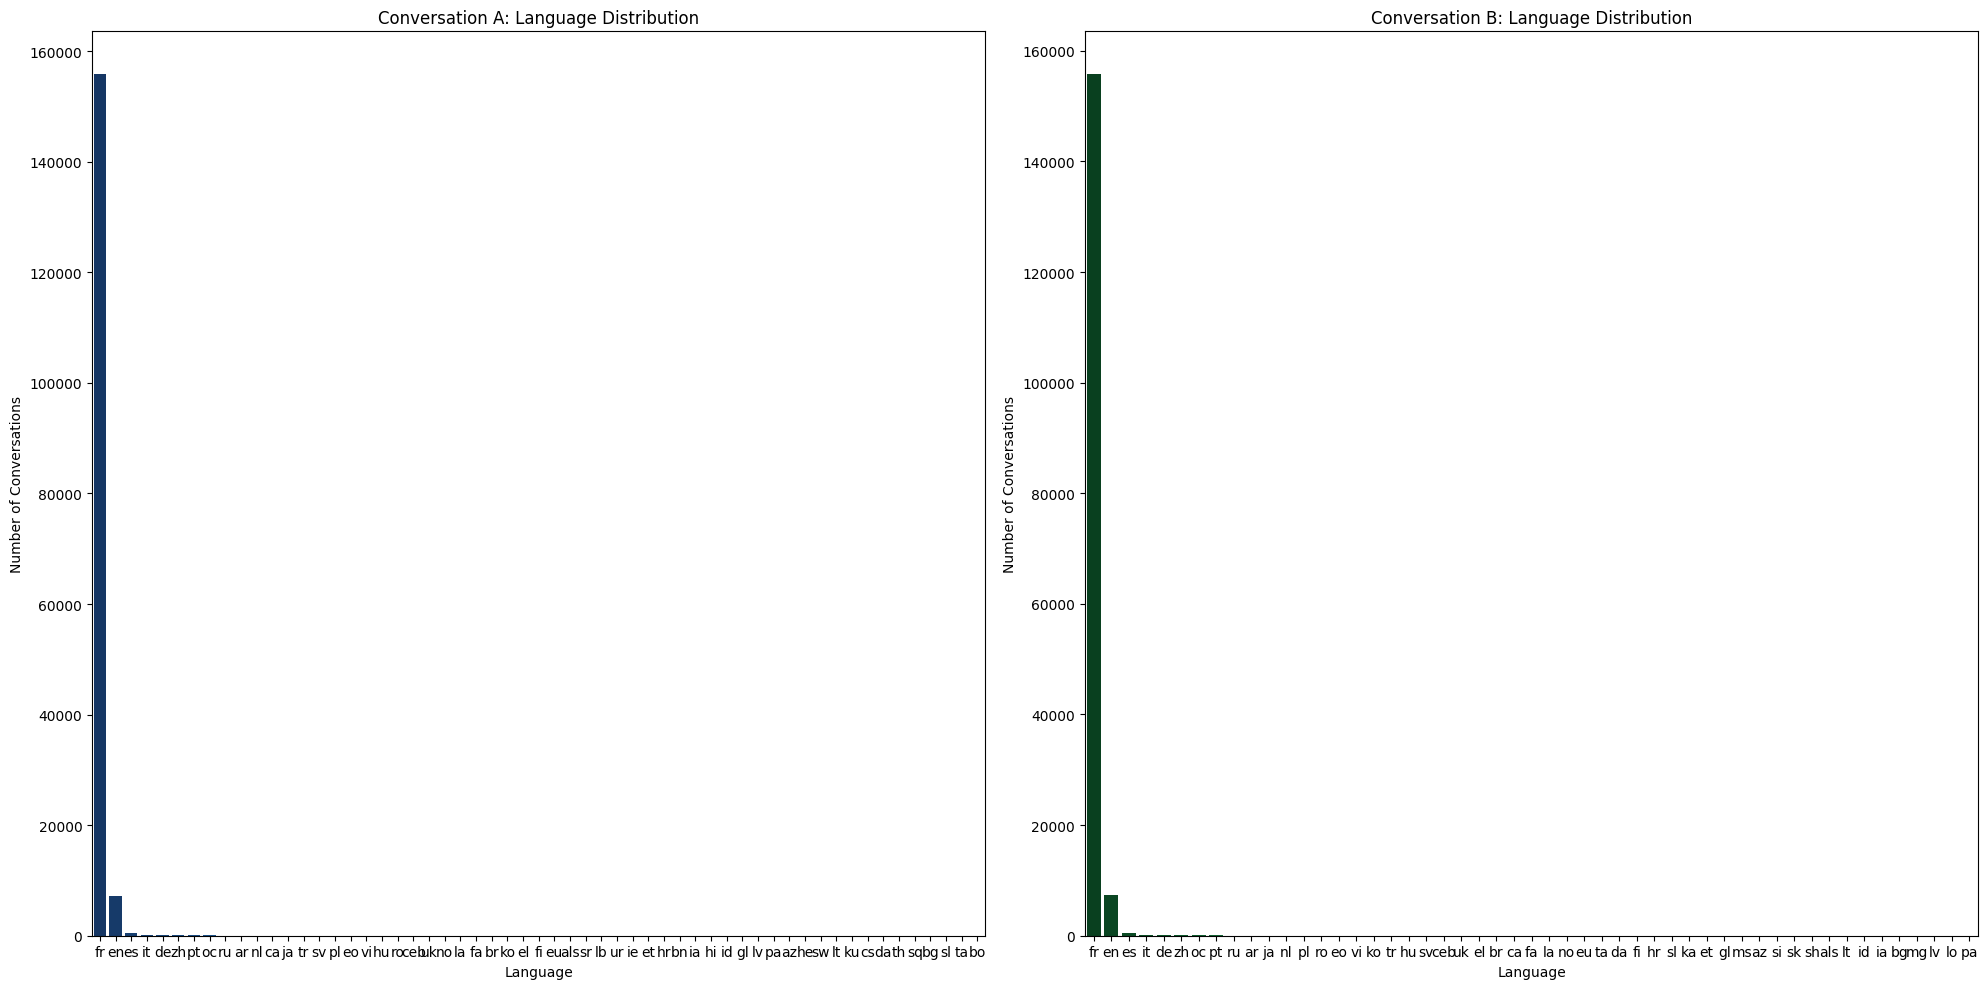

In [84]:
#Language distribution for conversation_a and conversation_b
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
sns.countplot(x=df_votes['lang_fasttext_a'], order=df_votes['lang_fasttext_a'].value_counts().index, palette="Blues_r")
plt.title("Conversation A: Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Conversations")

plt.subplot(1,2,2)
sns.countplot(x=df_votes['lang_fasttext_b'], order=df_votes['lang_fasttext_b'].value_counts().index, palette="Greens_r")
plt.title("Conversation B: Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Conversations")

plt.tight_layout()
plt.show()

/tmp/ipykernel_58/2347740725.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=match_counts.index.map({True:"Same", False:"Different"}), y=match_counts.values, palette="coolwarm")


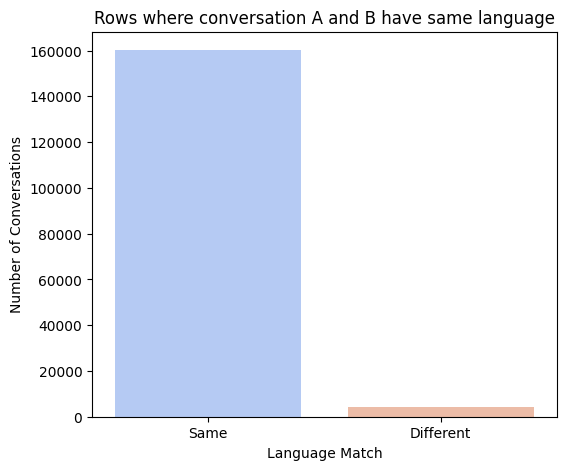

In [81]:
# Match vs Mismatch between conversation_a and conversation_b
df_votes['lang_match'] = df_votes['lang_fasttext_a'] == df_votes['lang_fasttext_b']
match_counts = df_votes['lang_match'].value_counts()

plt.figure(figsize=(6,5))
sns.barplot(x=match_counts.index.map({True:"Same", False:"Different"}), y=match_counts.values, palette="coolwarm")
plt.title("Rows where conversation A and B have same language")
plt.ylabel("Number of Conversations")
plt.xlabel("Language Match")
plt.show()


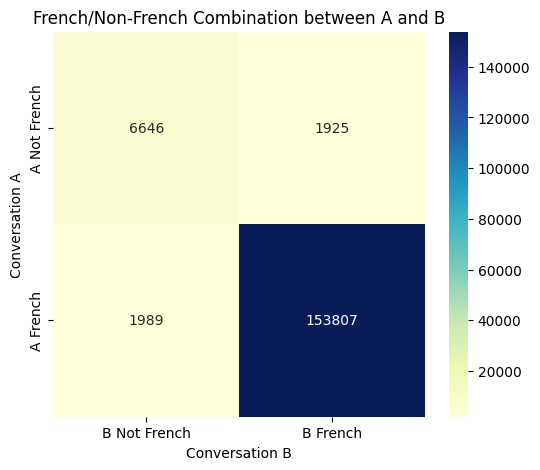

In [82]:
#French / Non-French combination summary (cross-tab)
summary = pd.crosstab(df_votes['lang_fasttext_a'] == 'fr', df_votes['lang_fasttext_b'] == 'fr')
summary.index = ['A Not French', 'A French']
summary.columns = ['B Not French', 'B French']

plt.figure(figsize=(6,5))
sns.heatmap(summary, annot=True, fmt="d", cmap="YlGnBu")
plt.title("French/Non-French Combination between A and B")
plt.ylabel("Conversation A")
plt.xlabel("Conversation B")
plt.show()

In [85]:
df_votes.to_parquet("/kaggle/working/df_votes_with_lang.parquet", engine="pyarrow", index=False)